# Week 6 – Ensemble Learning

## 🎯 Objective
Today I will focus on exploring Ensemble Learning techniques:

1. Bagging (Bootstrap Aggregating)
2. Boosting

### Learning Goals:
- Understand the difference between Bagging and Boosting.
- Implement Bagging using Random Forest.
- Implement Boosting using Gradient Boosting.
- Compare ensemble models.
- Evaluate performance using R², MAE, RMSE.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [3]:
# Load dataset
df = pd.read_csv('C:\\Users\\ASUS\\Desktop\\Data_Science_Internship\\Week_5\\Dataset\\insurance.csv')

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
# One-hot encoding categorical features
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [5]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest (Bagging) Performance")
print("R2 Score:", r2_score(y_test, y_pred_rf))
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

Random Forest (Bagging) Performance
R2 Score: 0.8523666810628521
MAE: 2657.7051697205243
RMSE: 4652.594245286397


In [6]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)

gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)

print("Gradient Boosting Performance")
print("R2 Score:", r2_score(y_test, y_pred_gb))
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))

Gradient Boosting Performance
R2 Score: 0.8588140349332668
MAE: 2515.7879822689433
RMSE: 4549.867515903515


In [7]:
comparison = pd.DataFrame({
    "Model": ["Random Forest (Bagging)", "Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,Random Forest (Bagging),0.852367,2657.705170,4652.594245
1,Gradient Boosting,0.858814,2515.787982,4549.867516


In [8]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'RF Importance': rf_model.feature_importances_,
    'GB Importance': gb_model.feature_importances_
})

feature_importance.sort_values(by='RF Importance', ascending=False)

,Feature,RF Importance,GB Importance
4,smoker_yes,0.608108,0.655245
1,bmi,0.210278,0.201850
0,age,0.138583,0.123461
2,children,0.020672,0.012891
3,sex_male,0.006937,0.001382
5,region_northwest,0.005522,0.003195
6,region_southeast,0.005061,0.000557
7,region_southwest,0.004839,0.001420


## 📌 Conclusion

### 🔹 Bagging (Random Forest):
- Reduces variance
- Prevents overfitting
- Works well on most datasets

### 🔹 Boosting (Gradient Boosting):
- Reduces bias
- Learns from previous errors
- Often achieves higher accuracy

### ✔ Today’s Outcome:
- Understood ensemble learning
- Implemented Bagging
- Implemented Boosting
- Compared model performance

# Week 6 – Advanced Boosting Models

## 🎯 Objective
Today I will implement advanced boosting algorithms:

1. XGBoost
2. LightGBM

### Learning Goals:
- Understand gradient boosting improvements.
- Implement XGBoost and LightGBM.
- Compare performance with traditional boosting.
- Evaluate using R², MAE, RMSE.

In [9]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost Performance")
print("R2 Score:", r2_score(y_test, y_pred_xgb))
print("MAE:", mean_absolute_error(y_test, y_pred_xgb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_xgb)))

XGBoost Performance
R2 Score: 0.8605462417509107
MAE: 2548.196160074763
RMSE: 4521.870275285161


In [10]:
lgbm_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

lgbm_model.fit(X_train, y_train)
y_pred_lgbm = lgbm_model.predict(X_test)

print("LightGBM Performance")
print("R2 Score:", r2_score(y_test, y_pred_lgbm))
print("MAE:", mean_absolute_error(y_test, y_pred_lgbm))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lgbm)))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000334 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 936, number of used features: 8
[LightGBM] [Info] Start training from score 13379.157302
LightGBM Performance
R2 Score: 0.8507773073581161
MAE: 2789.485400068576
RMSE: 4677.5713816802545


In [16]:
comparison = pd.DataFrame({
    "Model": ["XGBoost","Gradient Boosting"],
    "R2 Score": [
        r2_score(y_test, y_pred_xgb),
        r2_score(y_test, y_pred_lgbm)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_xgb),
        mean_absolute_error(y_test, y_pred_lgbm)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_xgb)),
        np.sqrt(mean_squared_error(y_test, y_pred_lgbm))
    ]
})

comparison

,Model,R2 Score,MAE,RMSE
0,XGBoost,0.860546,2548.19616,4521.870275
1,Gradient Boosting,0.850777,2789.48540,4677.571382


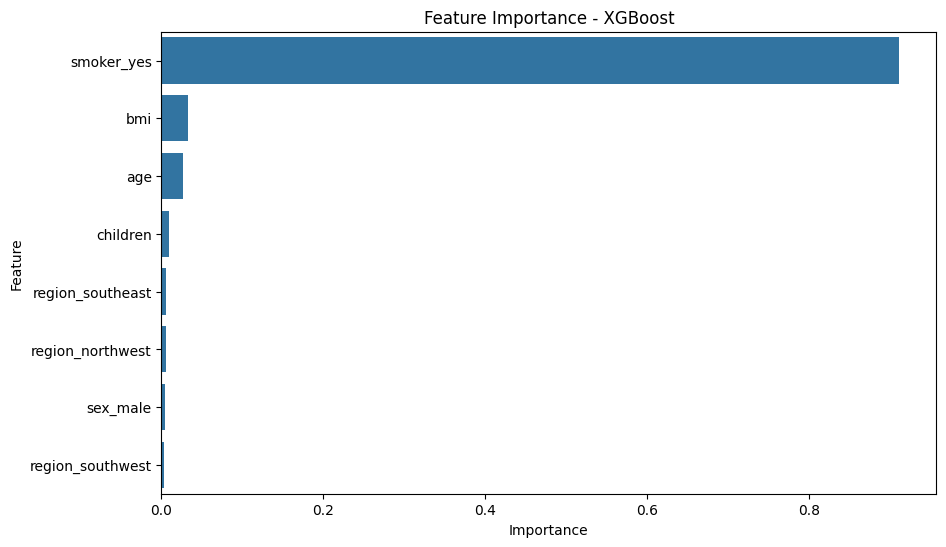

In [ ]:
importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Feature Importance - XGBoost")
plt.show()

## 📌 Conclusion

### 🔥 XGBoost:
- Regularized boosting
- Strong performance
- Slightly slower than LightGBM

### 🚀 LightGBM:
- Faster training
- Leaf-wise growth
- Efficient for large datasets

### ✔ Today’s Outcome:
- Implemented XGBoost
- Implemented LightGBM
- Compared advanced boosting models